# PINN Example: Learning a Forgetting Curve

A beginner-friendly Physics-Informed Neural Network (PINN) example. Instead of learning from data, the network learns from the differential equation describing how memory fades over time.

## 1. Imports

In [9]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

## 2. True Solution

In [2]:
t_np = np.linspace(0,10,200)
K_true = np.exp(-0.5*t_np)

## 3. Neural Network

In [3]:
class PINN(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(1,32),
            nn.Tanh(),
            nn.Linear(32,32),
            nn.Tanh(),
            nn.Linear(32,1)
        )

    def forward(self,t):
        return self.net(t)

model = PINN()

## 4. Physics Loss
Equation: dK/dt + 0.5K = 0

In [4]:
def physics_loss(model,t):

    t = t.clone().requires_grad_(True)

    K = model(t)

    dK_dt = torch.autograd.grad(
        K,
        t,
        grad_outputs=torch.ones_like(K),
        create_graph=True
    )[0]

    residual = dK_dt + 0.5*K

    return torch.mean(residual**2)

## 5. Initial Condition
At day 0, knowledge retained = 1

In [5]:
def ic_loss(model):

    t0 = torch.tensor([[0.0]])

    pred = model(t0)

    return (pred - 1.0)**2

## 6. Training

In [6]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

t_train = torch.linspace(
    0,
    10,
    200
).reshape(-1,1)

for epoch in range(5000):

    optimizer.zero_grad()

    loss = (
        physics_loss(model,t_train)
        + 100*ic_loss(model)
    )

    loss.backward()
    optimizer.step()

    if epoch % 500 == 0:
        print(f"Epoch {epoch} | Loss = {loss.item():.6f}")

Epoch 0 | Loss = 219.793610
Epoch 500 | Loss = 0.000581
Epoch 1000 | Loss = 0.000311
Epoch 1500 | Loss = 0.000225
Epoch 2000 | Loss = 0.000175
Epoch 2500 | Loss = 0.000125
Epoch 3000 | Loss = 0.000086
Epoch 3500 | Loss = 0.000061
Epoch 4000 | Loss = 0.000047
Epoch 4500 | Loss = 0.000039


## 7. Prediction

In [7]:
t_tensor = torch.tensor(
    t_np,
    dtype=torch.float32
).reshape(-1,1)

with torch.no_grad():
    K_pinn = model(t_tensor).numpy().flatten()

## 8. Visualization

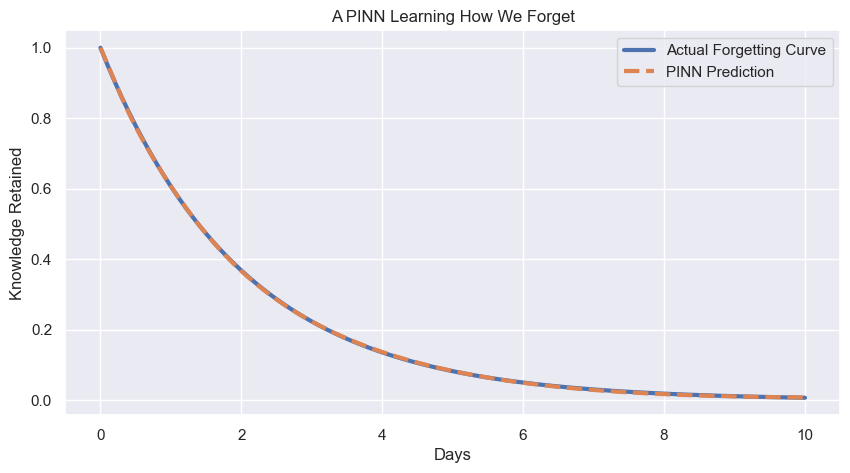

In [11]:
plt.figure(figsize=(10,5))

plt.plot(
    t_np,
    K_true,
    linewidth=3,
    label='Actual Forgetting Curve'
)

plt.plot(
    t_np,
    K_pinn,
    '--',
    linewidth=3,
    label='PINN Prediction'
)

plt.xlabel('Days')
plt.ylabel('Knowledge Retained')
plt.title('A PINN Learning How We Forget')
plt.legend()
plt.grid(True)
plt.savefig("pinn.png", dpi = 800)
plt.show()